In [1]:
import numpy as np
import pandas as pd

In [2]:
df=pd.read_excel(r"C:\Users\Acer\Downloads\translated_hindi_comments.xlsx")

In [3]:
df.head()

,Post,Labels Set
0,"""dr. bharat agravaal kaa kaalam: cheeni havaal...",normal
1,bharat kaa pantapradhaan pad kaa janmajaat umi...,fake
2,amariikii opan tennis men bharat ke rohan bopa...,normal
3,reportforssr . jinhonne film 'udataa panjaaba'...,normal
4,"kaise ghaṭegaa kacche tel kaa aayat, gadkari n...",normal


In [4]:
import pandas as pd
import numpy as np
import re
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import style
style.use('ggplot')
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9483 entries, 0 to 9482
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Post        9474 non-null   object
 1   Labels Set  9483 non-null   object
dtypes: object(2)
memory usage: 148.3+ KB


In [6]:
df=df.dropna()

In [7]:
df['Labels Set'] = df['Labels Set'].replace({'normal': 0, 'hate': 1})

In [8]:
df = df[df['Labels Set'] != 'd']
df = df[df['Labels Set'] != 'fake']

In [9]:
df = df.drop_duplicates()

<Axes: xlabel='Labels Set', ylabel='count'>

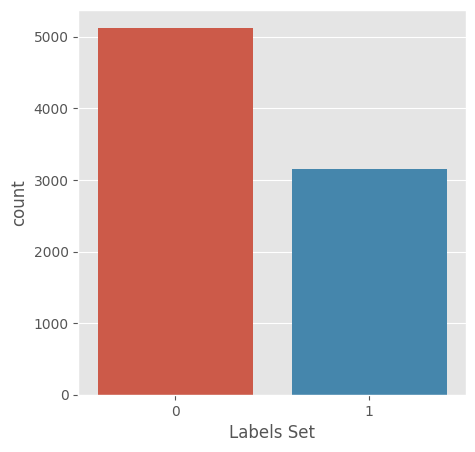

In [10]:
fig = plt.figure(figsize=(5,5))
sns.countplot(x='Labels Set', data = df)

In [11]:
def data_processing(Text):
    Text = Text.lower()
    Text = re.sub(r"https\S+|www\S+http\S+", '', Text, flags = re.MULTILINE)
    Text= re.sub(r'\@w+|\#','', Text)
    Text = re.sub(r'[^\w\s]','',Text)
    Text = re.sub(r'ð','',Text)
    Text_tokens = word_tokenize(Text)
    filtered_Text = [w for w in Text_tokens if not w in stop_words]
    return " ".join(filtered_Text)

In [12]:
df.Post = df['Post'].apply(data_processing)

In [13]:
from nltk.stem import WordNetLemmatizer

# Initialize lemmatizer
lemmatizer = WordNetLemmatizer()

# Function to lemmatize text
def lemmatizing(data):
    # Assuming 'data' is a string, you need to split it into words for lemmatization
    words = data.split()
    
    # Apply lemmatization to each word
    lemmatized_words = [lemmatizer.lemmatize(word) for word in words]
    
    # Join the lemmatized words back into a single string
    return ' '.join(lemmatized_words)

# Apply the lemmatizing function to each row in the 'Text' column
df['Post'] = df['Post'].apply(lemmatizing)


In [14]:
df.head()

,Post,Labels Set
0,dr bharat agravaal kaa kaalam cheeni havaalaa ...,0
2,amariikii opan tennis men bharat ke rohan bopa...,0
3,reportforssr jinhonne film udataa panjaaba ban...,0
4,kaise ghaṭegaa kacche tel kaa aayat gadkari ne...,0
7,sṭechuu aaph yuniṭii ban gaii sṭechuu aaph ḍuu...,1


In [15]:
vect = TfidfVectorizer(ngram_range=(1,2)).fit(df['Post'])

In [16]:
from sklearn.feature_extraction.text import TfidfVectorizer





feature_names = vect.get_feature_names_out()

# Print the number of features and the first 20 features
print("Number of features: {}\n".format(len(feature_names)))
print("First 20 features: \n{}".format(feature_names[:20]))


Number of features: 124051

First 20 features: 
['01' '01 hajaar' '01 laakh' '01 pratishat' '0130' '0130 juun' '02'
 '02 kilo' '022' '022 kii' '03' '03 nijii' '03 sintambar' '030916'
 '030916 user' '04' '04 maamale' '05' '05 kilo' '0506823156']


In [17]:
vect = TfidfVectorizer(ngram_range=(1,3)).fit(df['Post'])

In [18]:
feature_names = vect.get_feature_names_out()

# Print the number of features and the first 20 features
print("Number of features: {}\n".format(len(feature_names)))
print("First 20 features: \n{}".format(feature_names[:20]))

Number of features: 243006

First 20 features: 
['01' '01 hajaar' '01 hajaar bharaṇposhaṇ' '01 laakh' '01 laakh karod'
 '01 pratishat' '01 pratishat baagapat' '0130' '0130 juun' '0130 juun kii'
 '02' '02 kilo' '02 kilo arahar' '02 kilo bhunaa' '022' '022 kii'
 '022 kii giraavaṭ' '03' '03 nijii' '03 nijii meḍikal']


In [19]:
X = df['Post']
Y = df['Labels Set']
X = vect.transform(X)

# LOgistic_Regression

In [20]:
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)


In [21]:
print("Size of x_train:", (x_train.shape))
print("Size of y_train:", (y_train.shape))
print("Size of x_test: ", (x_test.shape))
print("Size of y_test: ", (y_test.shape))

Size of x_train: (6622, 243006)
Size of y_train: (6622,)
Size of x_test:  (1656, 243006)
Size of y_test:  (1656,)


In [23]:
# If your labels need to be binary:
threshold = 0.5  # Adjust the threshold based on your problem
y_train = (y_train > threshold).astype(int)
y_test = (y_test > threshold).astype(int)

# Train the model again
logreg = LogisticRegression()
logreg.fit(x_train, y_train)
logreg_predict = logreg.predict(x_test)
logreg_acc = accuracy_score(logreg_predict, y_test)
print("Test accuracy: {:.2f}%".format(logreg_acc * 100))


Test accuracy: 79.65%


In [22]:
logreg = LogisticRegression()
logreg.fit(x_train, y_train)
logreg_predict = logreg.predict(x_test)
logreg_acc = accuracy_score(logreg_predict, y_test)
print("Test accuarcy: {:.2f}%".format(logreg_acc*100))

ValueError: Unknown label type: unknown. Maybe you are trying to fit a classifier, which expects discrete classes on a regression target with continuous values.

In [24]:
print(confusion_matrix(y_test, logreg_predict))
print("\n")
print(classification_report(y_test, logreg_predict))

[[1012   27]
 [ 310  307]]


              precision    recall  f1-score   support

           0       0.77      0.97      0.86      1039
           1       0.92      0.50      0.65       617

    accuracy                           0.80      1656
   macro avg       0.84      0.74      0.75      1656
weighted avg       0.82      0.80      0.78      1656



# Naive_Bayes

In [25]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df['Post'],df['Labels Set'])

In [26]:
from sklearn.feature_extraction.text import CountVectorizer
v = CountVectorizer()
X_train_count = v.fit_transform(X_train.values)
X_train_count.toarray()[:2]

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=int64)

In [30]:
# Check the structure and type of y_test
print("y_test shape:", y_test.shape)
print("y_test type:", type(y_test))
print("y_test dtype:", y_test.dtype)

# Convert y_test to a 1D array if necessary
if isinstance(y_test, (np.ndarray, list)) and y_test.ndim > 1:
    y_test = np.ravel(y_test)  # Flatten to 1D array

# Ensure that y_test has the correct type (e.g., int or str)
y_test = y_test.astype(int) if y_test.dtype == 'object' else y_test

# Get the accuracy score
X_test_count = v.transform(X_test)
score = model.score(X_test_count, y_test)
print("Test accuracy: {:.2f}%".format(score * 100))


y_test shape: (2070,)
y_test type: <class 'pandas.core.series.Series'>
y_test dtype: object
Test accuracy: 81.93%


In [31]:
X_test_count = v.transform(X_test)
model.score(X_test_count, y_test)

0.8193236714975846

# SVM

In [32]:
tfidf_vectorizer = TfidfVectorizer(ngram_range=(1, 2),max_df=0.75, min_df=5, max_features=10000)

# TF-IDF feature matrix
tfidf = tfidf_vectorizer.fit_transform(df['Post'] )
tfidf

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 128478 stored elements and shape (8278, 6702)>

In [33]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report

In [35]:
import numpy as np

# Check the type and unique values of y
print("y type:", type(y))
print("y unique values:", np.unique(y))

# Convert to a 1D array if necessary
y = np.ravel(y) if isinstance(y, (np.ndarray, list)) and y.ndim > 1 else y

# Ensure that y has the correct type (e.g., int or str)
if y.dtype == 'object':
    # Try to convert to int if possible, or leave as str if categorical
    try:
        y = y.astype(int)
    except ValueError:
        pass  # Leave as str if it's categorical

# Split the data again
X_train_tfidf, X_test_tfidf, y_train, y_test = train_test_split(X.toarray(), y, random_state=42, test_size=0.2)

# Train the model
support = LinearSVC(random_state=20)
support.fit(X_train_tfidf, y_train)
y_preds = support.predict(X_test_tfidf)

# Calculate accuracy and print the report
acc3 = accuracy_score(y_test, y_preds)
report = classification_report(y_test, y_preds)
print(report)
print("SVM, Accuracy Score:", acc3)


y type: <class 'pandas.core.series.Series'>
y unique values: [0 1]
              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1039
           1       0.82      0.75      0.78       617

    accuracy                           0.84      1656
   macro avg       0.84      0.82      0.83      1656
weighted avg       0.84      0.84      0.84      1656

SVM, Accuracy Score: 0.8435990338164251


# Model Building

In [ ]:
from tensorflow import keras
comments_train, comments_test, labels_train, labels_test = train_test_split(
    df.Text, Label, test_size=0.3, random_state=42)

# Initialize instance for early stopping (used in all models)
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_accuracy",
    mode="max",
    patience=20,
    restore_best_weights=True)

# Specify dropout rate (used in all models) 
dropout_rate = 0.5

# Simple RNN

In [42]:
num_words = 5000 
tokenizer = tensorflow.keras.preprocessing.text.Tokenizer(
    num_words=num_words,
    filters='"!#$%&()*+,-./:;<=>?@[\\]^_`{|}~\t\n',
    lower=True, split=" ", char_level=False, oov_token=None)

# Fit tokenizer to training data  
tokenizer.fit_on_texts(comments_train)

# Save dictionary
word_index = tokenizer.word_index

# Display first 100 words of the dictionary
count = 0
for key, value in word_index.items():
    print(f"{key}: {value}")
    count += 1
    if count == 100:
        break
    
# Apply tokenizer to training and test data 
sequences_train = tokenizer.texts_to_sequences(comments_train)
sequences_test = tokenizer.texts_to_sequences(comments_test)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Tokenize the text data
tokenizer = Tokenizer(num_words=num_words)
tokenizer.fit_on_texts(comments_train)

# Convert text to sequences
sequences_train = tokenizer.texts_to_sequences(comments_train)
sequences_test = tokenizer.texts_to_sequences(comments_test)

# Pad the sequences
padded_sequences_train = pad_sequences(sequences_train, maxlen=max_length)
padded_sequences_test = pad_sequences(sequences_test, maxlen=max_length)
# Convert string labels to integers (e.g., 'positive' -> 1, 'negative' -> 0)
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
labels_train = label_encoder.fit_transform(labels_train)
labels_test = label_encoder.transform(labels_test)

max_length = 15
# Tokenize the text data
tokenizer = Tokenizer(num_words=num_words)
tokenizer.fit_on_texts(comments_train)

# Convert text to sequences
sequences_train = tokenizer.texts_to_sequences(comments_train)
sequences_test = tokenizer.texts_to_sequences(comments_test)

# Pad the sequences
padded_sequences_train = pad_sequences(sequences_train, maxlen=max_length)
padded_sequences_test = pad_sequences(sequences_test, maxlen=max_length)


# Display first 5 sequences
print(sequences_train[:5])  

# Apply sequence padding to obtain consistent sequence length 
max_length = 15
padded_sequences_train = keras.preprocessing.sequence.pad_sequences(
    sequences_train, 
    maxlen=max_length, 
    truncating="post", 
    padding="post"
    )
padded_sequences_test = keras.preprocessing.sequence.pad_sequences(
    sequences_test, 
    maxlen=max_length, 
    truncating="post", 
    padding="post"
    )

# Display first 5 padded sequences
print(padded_sequences_train[:5])

# Specify the number of dimensions of the word vectors in the embedding layer
word_vector_dim = 50

# Specify model
model1 = keras.models.Sequential()
model1.add(keras.layers.Embedding(input_dim=num_words+1,  # number of words in tokenizer +1 for the "0" used for padding 
                                  output_dim=word_vector_dim,
                                  mask_zero=True, 
                                  input_shape=(max_length,)))  # Set 'input_shape'

model1.add(keras.layers.SimpleRNN(128, 
                                  return_sequences=True,
                                  dropout=dropout_rate,
                                  recurrent_dropout=dropout_rate))
model1.add(keras.layers.SimpleRNN(128, 
                                  dropout=dropout_rate, 
                                  recurrent_dropout=dropout_rate))
model1.add(keras.layers.Dense(64, activation="relu"))
model1.add(keras.layers.Dense(1, activation="sigmoid"))

# Summarize model 
model1.summary()

# Compile model
optimizer = keras.optimizers.Adam(learning_rate=0.001)
model1.compile(optimizer=optimizer, 
               loss="binary_crossentropy",
               metrics=["accuracy"])

# Fit model
model1_history = model1.fit(padded_sequences_train, labels_train,
                            epochs=100, batch_size=8,
                            validation_data=(padded_sequences_test, labels_test),
                            callbacks=early_stopping)
  

# Save model    
# model1.save("saved_models/model1")

# # Load model
# model1 = keras.models.load_model("saved_models/model1")

# Learning curve: Loss
plt.plot(model1_history.history["loss"], label="Train Loss")
plt.plot(model1_history.history["val_loss"], label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()
    
# Learning curve: Accuracy
plt.plot(model1_history.history["accuracy"], label="Train Accuracy")
plt.plot(model1_history.history["val_accuracy"], label="Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# Evaluate model: Accuracy for training and test data
train_score_model1 = model1.evaluate(padded_sequences_train, labels_train)
test_score_model1 = model1.evaluate(padded_sequences_test, labels_test)
print("Accuracy Train data: ", train_score_model1[1])
print("Accuracy Test data: ", test_score_model1[1])

# Predicted labels for test data 
labels_pred_prob_model1 = model1.predict(padded_sequences_test)
labels_pred_model1 = labels_pred_prob_model1.copy()
labels_pred_model1[labels_pred_model1 >= 0.5] = 1
labels_pred_model1[labels_pred_model1 < 0.5] = 0

# Evaluate model: Classification report for test data
print("Classification Report: Model 1 (SimpleRNN)")
print(classification_report(labels_test, labels_pred_model1))

# Evaluate model: Confusion matrix for test data
cm = confusion_matrix(labels_test, labels_pred_model1)
cm_disp = ConfusionMatrixDisplay(cm)
cm_disp.plot()

# Illustrative examples: True vs. predicted labels for clear and obvious hate speech 
for i in [236, 207, 15, 29, 183]:
    print(f"Comment: {comments_test[i]}")
    print(f"True label: {labels_test[i]}")
    print(f"Predicted label: {int(labels_pred_model1[i][0])}")
    print("===")

NameError: name 'tensorflow' is not defined

In [ ]:
sfsdfs

In [ ]:
import tensorflow as tf
print(tf.__version__) 

In [41]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences


In [ ]:
# Check for NaN values and types
print(df['Text'].isnull().sum())  # Count NaN values
print(df['Text'].apply(type).value_counts())  # Check data types


# LSTM

In [ ]:
# Initialize tokenizer 
num_words = 5000  # maximum number of unique words in the dictionary of the tokenizer
tokenizer = keras.preprocessing.text.Tokenizer(
    num_words=num_words,
    filters='"!#$%&()*+,-./:;<=>?@[\\]^_`{|}~\t\n',
    lower=True, split=" ", char_level=False, oov_token=None)

# Fit tokenizer to training data  
tokenizer.fit_on_texts(comments_train)

# Apply tokenizer to training and test data 
sequences_train = tokenizer.texts_to_sequences(comments_train)
sequences_test = tokenizer.texts_to_sequences(comments_test)  

# Apply sequence padding to obtain consistent sequence length 
max_length = 150
padded_sequences_train = keras.preprocessing.sequence.pad_sequences(
    sequences_train, 
    maxlen=max_length, 
    truncating="post", 
    padding="post"
    )
padded_sequences_test = keras.preprocessing.sequence.pad_sequences(
    sequences_test, 
    maxlen=max_length, 
    truncating="post", 
    padding="post"
    )

# Specify the number of dimensions of the word vectors in the embedding layer
word_vector_dim = 50

# Specify model
model2 = keras.models.Sequential()
model2.add(keras.layers.Embedding(input_dim=num_words + 1,  # number of words in tokenizer + 1 for padding
                                  output_dim=word_vector_dim, 
                                  mask_zero=True))
model2.add(keras.layers.Input(shape=(max_length,)))


model2.add(keras.layers.LSTM(128, 
                             return_sequences=True,
                             dropout=dropout_rate, 
                             recurrent_dropout=dropout_rate))
model2.add(keras.layers.LSTM(128, 
                             dropout=dropout_rate, 
                             recurrent_dropout=dropout_rate))
model2.add(keras.layers.Dense(64, activation="relu"))
model2.add(keras.layers.Dense(1, activation="sigmoid"))

# Summarize model
model2.summary()

# Compile model
optimizer = keras.optimizers.Adam(learning_rate=0.001)
model2.compile(optimizer=optimizer, 
               loss="binary_crossentropy",
               metrics=["accuracy"])

# Fit model
model2 = keras.Sequential()

model2.add(keras.layers.Embedding(input_dim=num_words + 1,  # number of words in tokenizer + 1 for padding
                                  output_dim=word_vector_dim, 
                                  input_length=max_length,  # Only needed if you want fixed input length
                                  mask_zero=True))

# Add other layers (e.g., LSTM, Dense, etc.)


# Save model    
model2.save("saved_models/model2")

# Load model
model2 = keras.models.load_model("saved_models/model2")

# Learning curve: Loss
plt.plot(model2_history.history["loss"], label="Train Loss")
plt.plot(model2_history.history["val_loss"], label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()
    
# Learning curve: Accuracy
plt.plot(model2_history.history["accuracy"], label="Train Accuracy")
plt.plot(model2_history.history["val_accuracy"], label="Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# Evaluate model: Accuracy for training and test data
train_score_model2 = model2.evaluate(padded_sequences_train, labels_train)
test_score_model2 = model2.evaluate(padded_sequences_test, labels_test)
print("Accuracy Train data: ", train_score_model2[1])
print("Accuracy Test data: ", test_score_model2[1])

# Predicted labels for test data 
labels_pred_prob_model2 = model2.predict(padded_sequences_test)
labels_pred_model2 = labels_pred_prob_model2.copy()
labels_pred_model2[labels_pred_model2 >= 0.5] = 1
labels_pred_model2[labels_pred_model2 < 0.5] = 0

# Evaluate model: Classification report for test data
print("Classification Report: Model 2 (LSTM)")
print(classification_report(labels_test, labels_pred_model2))

# Evaluate model: Confusion matrix for test data
cm = confusion_matrix(labels_test, labels_pred_model2)
cm_disp = ConfusionMatrixDisplay(cm)
cm_disp.plot()

# Illustrative examples: True vs. predicted labels for clear and obvious hate speech 
for i in [236, 207, 15, 29, 183]:
    print(f"Comment: {comments_test[i]}")
    print(f"True label: {labels_test[i]}")
    print(f"Predicted label: {int(labels_pred_model2[i][0])}")
    print("===")
    

In [ ]:
from keras.preprocessing.text import Tokenizer

# Sample texts
texts = ["I love programming.", "Deep learning is fascinating."]

# Create a tokenizer
tokenizer = Tokenizer(num_words=10000)  # limit the number of words to 10,000
tokenizer.fit_on_texts(texts)            # fit on texts

# Convert texts to sequences
sequences = tokenizer.texts_to_sequences(texts)
print(sequences)  # e.g., [[1, 2], [3, 4, 5]]


In [ ]:
import tensorflow as tf
import tensorflow_hub as hub

print("TensorFlow Version:", tf.__version__)
print("TensorFlow Hub Version:", hub.__version__)


# fine tune_BERT

In [ ]:
import tensorflow as tf
text_input = keras.layers.Input(shape=(), dtype=tf.string, name="Text")


# Preprocess the text inputs using the BERT preprocessing layer
import tensorflow_hub as hub

# Now use hub to load the BERT preprocessor
preprocessor = hub.KerasLayer("https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3",
                              name="preprocessing")

preprocessed_inputs = preprocessor(text_input)  # sequence length of preprocessed inputs is 128 tokens

# Load the BERT model
bert = hub.KerasLayer("https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-4_H-512_A-8/2",
                      trainable=True, 
                      name="BERT")

# Pass the preprocessed text inputs through the BERT model
bert_outputs = bert(preprocessed_inputs)

# Extract the pooled output from the BERT outputs
pooled_bert_output = bert_outputs["pooled_output"]

# Apply dropout regularization
pooled_bert_output = keras.layers.Dropout(dropout_rate)(pooled_bert_output)

# Fine-tune the BERT model with dense layers for the hate speech detection task
dense = keras.layers.Dense(128, activation="relu")(pooled_bert_output)
outputs = keras.layers.Dense(1, activation="sigmoid", name="classifier")(dense)

# Create model
model3 = keras.Model(inputs=text_input, outputs=outputs)

# Summarize model 
model3.summary()

# Compile model 
optimizer = keras.optimizers.Adam(learning_rate=0.0001)
model3.compile(optimizer=optimizer, 
               loss="binary_crossentropy",
               metrics=["accuracy"])

# Fit model
model3_history = model3.fit(comments_train, labels_train,
                            epochs=100, batch_size=8,
                            validation_data=(comments_test, labels_test),
                            callbacks=early_stopping)  

# Save model    
model3.save("saved_models/model3")

# Load model
model3 = keras.models.load_model("saved_models/model3")

# Learning curve: Loss
plt.plot(model3_history.history["loss"], label="Train Loss")
plt.plot(model3_history.history["val_loss"], label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()
    
# Learning curve: Accuracy
plt.plot(model3_history.history["accuracy"], label="Train Accuracy")
plt.plot(model3_history.history["val_accuracy"], label="Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# Evaluate model: Accuracy for training and test data
train_score_model3 = model3.evaluate(comments_train, labels_train)
test_score_model3 = model3.evaluate(comments_test, labels_test)
print("Accuracy Train data: ", train_score_model3[1])
print("Accuracy Test data: ", test_score_model3[1])

# Predicted labels for test data 
labels_pred_prob_model3 = model3.predict(comments_test)
labels_pred_model3 = labels_pred_prob_model3.copy()
labels_pred_model3[labels_pred_model3 >= 0.5] = 1
labels_pred_model3[labels_pred_model3 < 0.5] = 0

# Evalute model: Classification report for test data
print("Classification Report: Model 3 (Bert)")
print(classification_report(labels_test, labels_pred_model3))

# Evaluate model: Confusion matrix for test data
cm = confusion_matrix(labels_test, labels_pred_model3)
cm_disp = ConfusionMatrixDisplay(cm)
cm_disp.plot()
 
# Illustrative examples: True vs. predicted labels for clear and obvious hate speech 
for i in [236, 207, 15, 29, 183]:
    print(f"Comment: {comments_test[i]}")
    print(f"True label: {labels_test[i]}")
    print(f"Predicted label: {int(labels_pred_model3[i][0])}")
    print("===")
  
# Illustrative examples: Comparing SimpleRNN, LSTM and fine-tuned BERT 
for i in [236, 207, 15, 29, 183]:
    print(f"Comment: {comments_test[i]}")
    print(f"True label: {labels_test[i]}")
    print(f"SimpleRNN: {int(labels_pred_model1[i][0])}")
    print(f"LSTM: {int(labels_pred_model2[i][0])}")
    print(f"Fine-Tuned BERT: {int(labels_pred_model3[i][0])}")
    print("===")

In [ ]:
fig = plt.figure(figsize=(7,7))
colors = ("red", "gold")
wp = {'linewidth':2, 'edgecolor':"black"}
tags = df['lebel'].value_counts()
explode = (0.1, 0.1)
tags.plot(kind='pie',autopct = '%1.1f%%', shadow=True, colors = colors, startangle =90, 
         wedgeprops = wp, explode = explode, lebel='')
plt.title('Distribution of sentiments')

In [ ]:
text = ' '.join([word for word in non_hate_tweets['text']])
plt.figure(figsize=(20,15), facecolor='None')
wordcloud = WordCloud(max_words=500, width=1600, height=800).generate(text)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most frequent words in non hate tweets', fontsize = 19)
plt.show()

In [ ]:
def data_processing(tweet):
    tweet = tweet.lower()
    tweet = re.sub(r"https\S+|www\S+http\S+", '', tweet, flags = re.MULTILINE)
    tweet = re.sub(r'\@w+|\#','', tweet)
    tweet = re.sub(r'[^\w\s]','',tweet)
    tweet = re.sub(r'ð','',tweet)
    tweet_tokens = word_tokenize(tweet)
    filtered_tweets = [w for w in tweet_tokens if not w in stop_words]
    return " ".join(filtered_tweets)

In [ ]:
df.tweet = df['text'].apply(data_processing)


In [ ]:
 tokenized_tweet=df['text_clean']=df['text'].apply(clean)